###                                                        Food Delivery Analysis

### Importing Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Loading Dataset

In [3]:
import pandas as pd
df = pd.read_csv(r"C:\Users\jhothi sri\OneDrive\Documents\food_delivery_dataset.csv")
df.head()

,order_id,user_id,restaurant_id,order_date,total_amount,name,city,membership,restaurant_name,cuisine,rating
0,1,2508,450,18-02-2023,842.97,User_2508,Hyderabad,Regular,Restaurant_450,Mexican,3.2
1,2,2693,309,18-01-2023,546.68,User_2693,Pune,Regular,Restaurant_309,Indian,4.5
2,3,2084,107,15-07-2023,163.93,User_2084,Chennai,Gold,Restaurant_107,Mexican,4.0
3,4,319,224,04-10-2023,1155.97,User_319,Bangalore,Gold,Restaurant_224,Chinese,4.8
4,5,1064,293,25-12-2023,1321.91,User_1064,Pune,Regular,Restaurant_293,Italian,3.0


### DataAnalysis and Cleaning

In [4]:
print(df.shape)

(10000, 11)


In [5]:
print(df.columns)

Index(['order_id', 'user_id', 'restaurant_id', 'order_date', 'total_amount',
       'name', 'city', 'membership', 'restaurant_name', 'cuisine', 'rating'],
      dtype='object')


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         10000 non-null  int64  
 1   user_id          10000 non-null  int64  
 2   restaurant_id    10000 non-null  int64  
 3   order_date       10000 non-null  object 
 4   total_amount     10000 non-null  float64
 5   name             10000 non-null  object 
 6   city             10000 non-null  object 
 7   membership       10000 non-null  object 
 8   restaurant_name  10000 non-null  object 
 9   cuisine          10000 non-null  object 
 10  rating           10000 non-null  float64
dtypes: float64(2), int64(3), object(6)
memory usage: 859.5+ KB
None


In [7]:
print(df.describe())

          order_id       user_id  restaurant_id  total_amount        rating
count  10000.00000  10000.000000   10000.000000  10000.000000  10000.000000
mean    5000.50000   1504.117700     251.016700    801.162412      4.045430
std     2886.89568    861.727776     144.622558    405.458753      0.606531
min        1.00000      1.000000       1.000000    100.200000      3.000000
25%     2500.75000    761.000000     127.000000    446.310000      3.500000
50%     5000.50000   1508.000000     251.000000    806.295000      4.100000
75%     7500.25000   2250.250000     376.000000   1149.227500      4.600000
max    10000.00000   3000.000000     500.000000   1499.830000      5.000000


In [8]:
print(df.index)

RangeIndex(start=0, stop=10000, step=1)


### Missing values

In [9]:
df.isnull().sum()

order_id           0
user_id            0
restaurant_id      0
order_date         0
total_amount       0
name               0
city               0
membership         0
restaurant_name    0
cuisine            0
rating             0
dtype: int64

### Remove duplicates

In [10]:
df = df.drop_duplicates()

### Date conversion

In [11]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    dayfirst=True
)

df.head()

,order_id,user_id,restaurant_id,order_date,total_amount,name,city,membership,restaurant_name,cuisine,rating
0,1,2508,450,2023-02-18,842.97,User_2508,Hyderabad,Regular,Restaurant_450,Mexican,3.2
1,2,2693,309,2023-01-18,546.68,User_2693,Pune,Regular,Restaurant_309,Indian,4.5
2,3,2084,107,2023-07-15,163.93,User_2084,Chennai,Gold,Restaurant_107,Mexican,4.0
3,4,319,224,2023-10-04,1155.97,User_319,Bangalore,Gold,Restaurant_224,Chinese,4.8
4,5,1064,293,2023-12-25,1321.91,User_1064,Pune,Regular,Restaurant_293,Italian,3.0


### Feature Engineering

In [12]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='%d-%m-%Y'
)

df['Month'] = df['order_date'].dt.month

df['Day'] = df['order_date'].dt.day_name()

In [14]:
df[['order_date','Month','Day']].head()

,order_date,Month,Day
0,2023-02-18,2,Saturday
1,2023-01-18,1,Wednesday
2,2023-07-15,7,Saturday
3,2023-10-04,10,Wednesday
4,2023-12-25,12,Monday


### Aggregations

In [15]:
# City-wise Revenue
city_revenue = df.groupby('city')['total_amount'].sum()

print(city_revenue)

city
Bangalore    2206946.58
Chennai      1990513.03
Hyderabad    1889366.58
Pune         1924797.93
Name: total_amount, dtype: float64


In [16]:
#Restaurant-wise orders
restaurant_orders = df.groupby('restaurant_name')['order_id'].count()

print(restaurant_orders)

restaurant_name
Restaurant_1      16
Restaurant_10     25
Restaurant_100    26
Restaurant_101    17
Restaurant_102    21
                  ..
Restaurant_95     17
Restaurant_96     26
Restaurant_97     23
Restaurant_98     16
Restaurant_99     16
Name: order_id, Length: 500, dtype: int64


In [17]:
# Average rating by city
city_rating = df.groupby('city')['rating'].mean()

print(city_rating)

city
Bangalore    4.027445
Chennai      4.057716
Hyderabad    4.049191
Pune         4.049671
Name: rating, dtype: float64


In [18]:
# Average spending by membership
membership_spending = df.groupby('membership')['total_amount'].mean()

print(membership_spending)

membership
Gold       797.145556
Regular    805.158434
Name: total_amount, dtype: float64


### Data Visualizations

### Graph 1: Top Restaurants

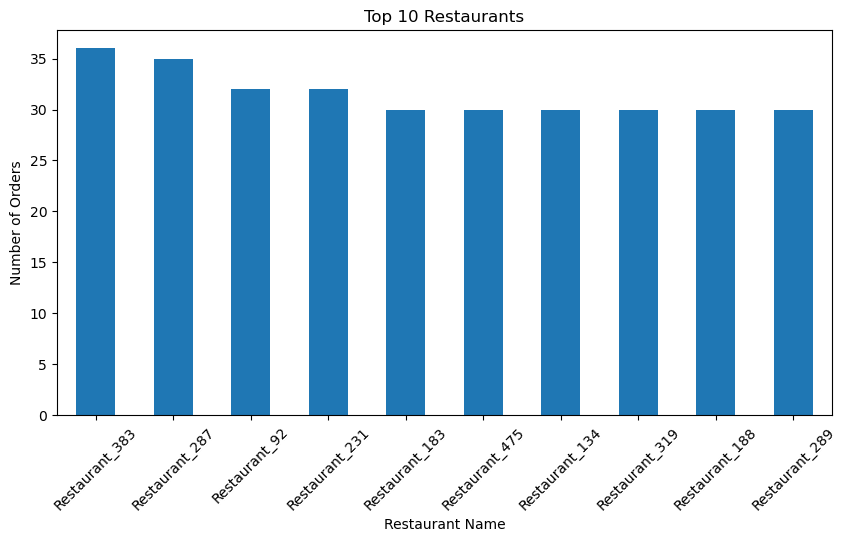

In [24]:
top_restaurants = df['restaurant_name'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_restaurants.plot(kind='bar')

plt.xticks(rotation=45)

plt.xlabel('Restaurant Name')

plt.ylabel('Number of Orders')

plt.title('Top 10 Restaurants')

plt.show()

### Graph 2: Cuisine Analysis

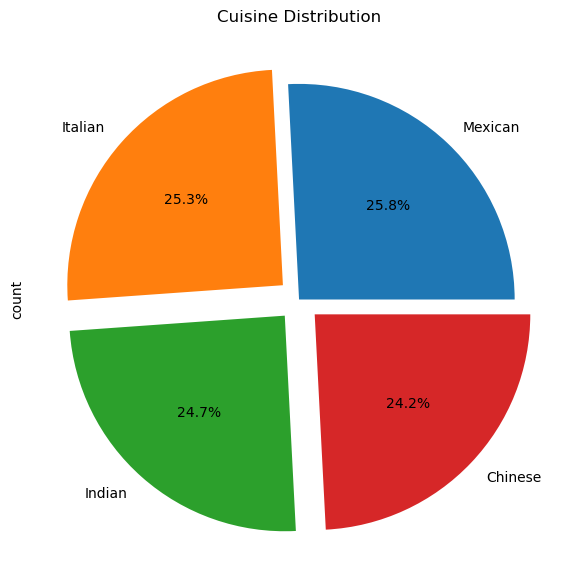

In [28]:
plt.figure(figsize=(7,7))

df['cuisine'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',explode=(0,0.1,0.1,0.1)
)

plt.title("Cuisine Distribution")

plt.show()

### Graph 3: City Analysis

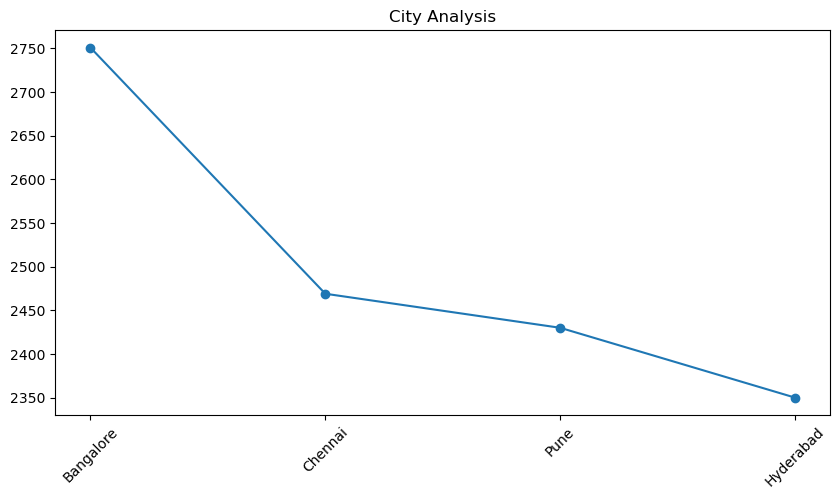

In [17]:
city_count = df['city'].value_counts()

plt.figure(figsize=(10,5))

plt.plot(
    city_count.index,
    city_count.values,
    marker='o'
)

plt.xticks(rotation=45)

plt.title("City Analysis")

plt.show()

### Graph 4: Membership Analysis

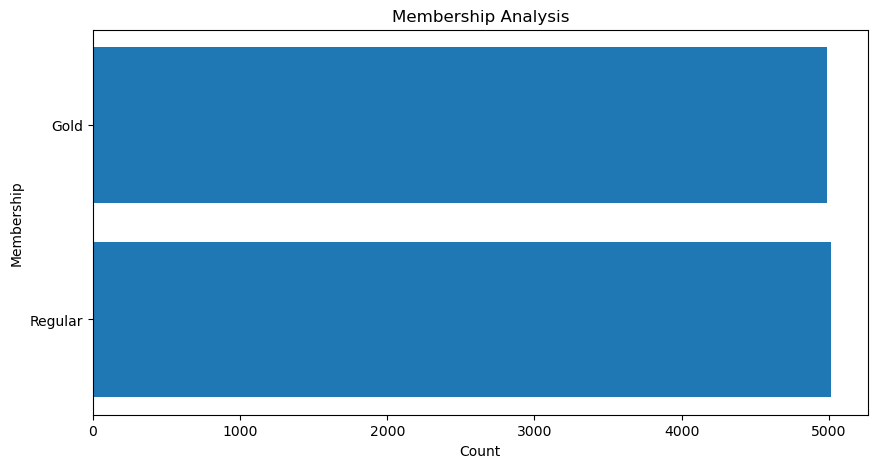

In [23]:
membership_count = df['membership'].value_counts()

plt.figure(figsize=(10,5))

plt.barh(
    membership_count.index,
    membership_count.values
)

plt.xlabel('Count')

plt.ylabel('Membership')

plt.title('Membership Analysis')

plt.show()

### Graph 5: Rating Distribution

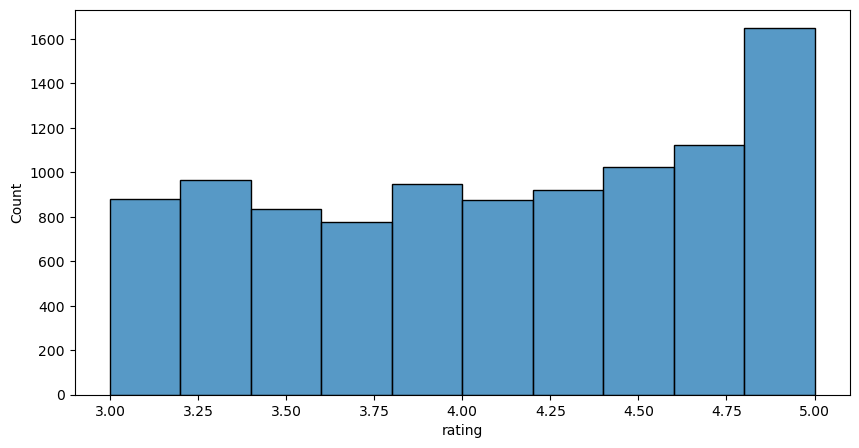

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['rating'],
    bins=10
)

plt.show()

### Graph 6: Revenue Analysis

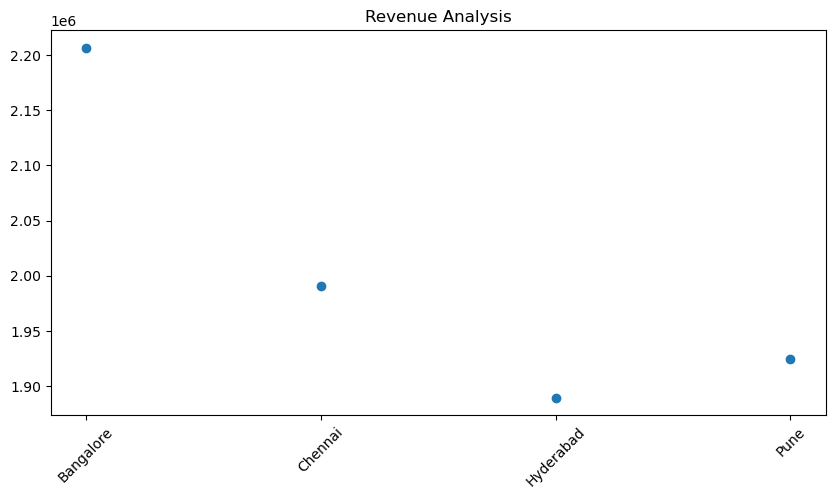

In [19]:
city_revenue = df.groupby(
    'city'
)['total_amount'].sum().reset_index()

plt.figure(figsize=(10,5))

plt.scatter(
    city_revenue['city'],
    city_revenue['total_amount']
)

plt.xticks(rotation=45)

plt.title("Revenue Analysis")

plt.show()

### Graph 7: Monthly Orders

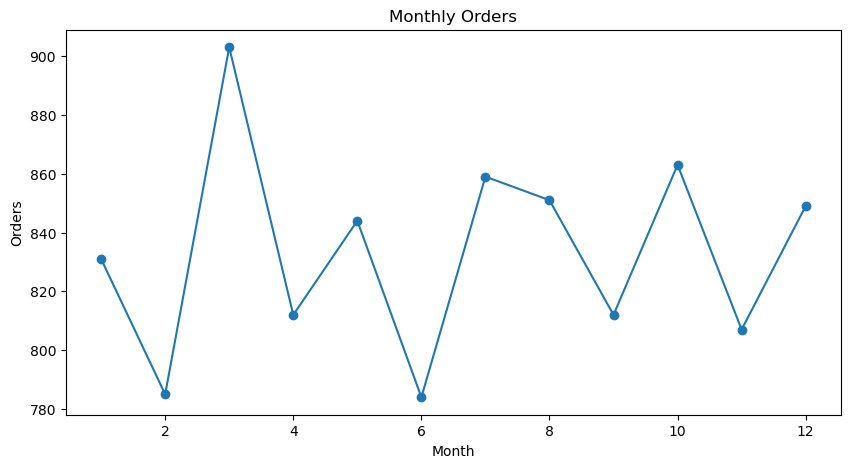

In [20]:
monthly_orders = df['Month'].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker='o'
)

plt.title("Monthly Orders")

plt.xlabel("Month")

plt.ylabel("Orders")

plt.show()

### Graph 8: Correlation Heatmap

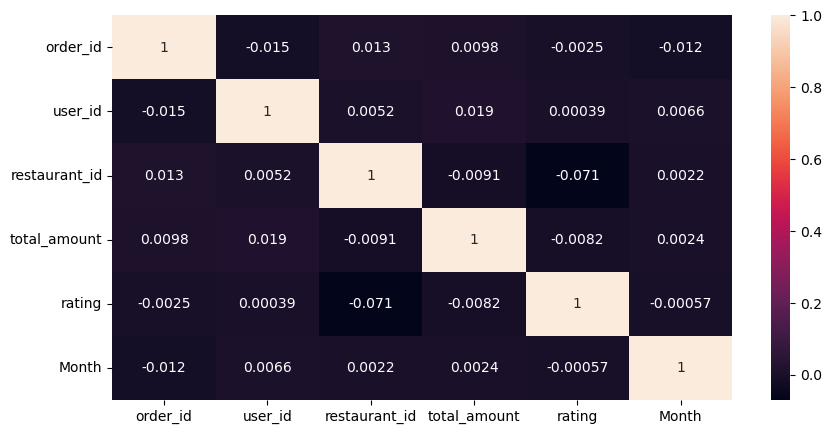

In [19]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.show()

### Business Insights


 1. Most popular restaurants were identified.

2. Most ordered cuisines were identified.

3. Highest revenue generating cities were identified.

4. Customer ratings were analyzed.

5. Membership distribution was analyzed.

6. Monthly ordering trends were identified.

7. Weekend and weekday ordering patterns were studied.